In [1]:
import gymnasium as gym
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
sys.path.append("..")

# Examine the environment

In [2]:
from rlc.envs.fogofwar import FogGridEnv
env = FogGridEnv(render_mode="rgb_array")

print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Render modes:      {env.metadata['render_modes']}")

obs, info = env.reset(seed=42)
print(f"Initial observation: {obs}  (row={obs // env.width}, col={obs % env.width})")

Observation space: Discrete(64)
Action space:      Discrete(4)
Render modes:      ['rgb_array']
Initial observation: 0  (row=0, col=0)


## Defining a fixed map layout for experimentation

In [3]:
env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density=0.08,
    trap_density=0.05,
)

env.reset(seed = 41)

env.print_map()

A . . X . . . . . . . .
O . . . . . . . . . X .
. . O . . . X . . . . .
X . . . . . X . O . . .
. . . O . . . . . . O .
. O O . . . . . . . . .
. . . . . . . . . . . .
. . . . . O . . . . O .
. . . . . . . . . . . .
. . . . X . . . . X . .
. . O . . . . . . . . .
. . . . . . . . O . . G


In [4]:
# based of a randomized map with seed = 41

fixed_obstacle_tiles = [(4, 10),
 (3, 8),
 (7, 5),
 (4, 3),
 (7, 10),
 (5, 1),
 (2, 2),
 (1, 0),
 (11, 8),
 (10, 2),
 (5, 2)]

fixed_trap_tiles = [(9, 9), (0, 3), (3, 0), (2, 6), (1, 10), (3, 6), (9, 4)]


# Experiments

## 1st Case
- Regular tabular Q-Learning with a fixed map layout. The most basic example to start defining the elements of the project.

In [5]:
# Two environment instances: one for training, one for evaluation.

from rlc.utils.training import train
from rlc.agents.q_learning import QLearningAgent
run_seeds = [42, 12, 33, 100, 133, 24, 99, 56, 1, 72]

In [6]:

print(len(run_seeds))
histories = []
results = []
for seed in run_seeds:
    train_env = FogGridEnv(
        height=12,
        width=12,
        start_pos=(0, 0),
        goal_pos=(11, 11),
        randomize_map=False,
        obstacle_tiles= fixed_obstacle_tiles,
        trap_tiles=fixed_trap_tiles,
        render_mode="rgb_array")

    eval_env = FogGridEnv(
        height=12,
        width=12,
        start_pos=(0, 0),
        goal_pos=(11, 11),
        randomize_map=False,
        obstacle_tiles= fixed_obstacle_tiles,
        trap_tiles=fixed_trap_tiles,
        render_mode="rgb_array")

    agent = QLearningAgent(
        n_states=train_env.observation_space.n,
        n_actions=train_env.action_space.n,
        alpha=0.1,
        gamma=1.0,
        epsilon_start=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.995,
        seed= seed
    )

    history = train(
        agent,
        train_env,
        n_episodes=5000,
        max_steps_per_episode=200,
        eval_every=100,
        eval_episodes=100,
        eval_env=eval_env,
        eval_max_steps=200,
        progress=True,
        seed=seed
    )

    print(f"Final epsilon:                     {agent.epsilon:.3f}")
    print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
    print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
        f"(std {history.eval_std_returns[-1]:.1f})")
    print(f"Final evaluation success rate: " f"{history.eval_success_rate[-1] * 100:.1f}%")
    print(f"Final mean episode length: " f"{history.eval_mean_len[-1]:.1f} steps")

    train_succ_rate = np.mean(history.eps_successess)
    histories.append(history)

    print(f"Training success rate: " f"{train_succ_rate * 100:.1f}%")
    
    # no weights since no VFA
    results.append([agent.epsilon, np.mean(history.episode_returns[-50:]), history.eval_mean_returns[-1],
                        history.eval_std_returns[-1], np.nan,history.eval_success_rate[-1] * 100,
                        history.eval_mean_len[-1], train_succ_rate * 100])

10


Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    77.4
Final greedy evaluation return:    79.0 (std 0.0)
Final evaluation success rate: 100.0%
Final mean episode length: 22.0 steps
Training success rate: 99.1%


Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    76.3
Final greedy evaluation return:    79.0 (std 0.0)
Final evaluation success rate: 100.0%
Final mean episode length: 22.0 steps
Training success rate: 99.0%


...

Final epsilon:                     0.050
Mean return, last 50 train eps:    77.3
Final greedy evaluation return:    79.0 (std 0.0)
Final evaluation success rate: 100.0%
Final mean episode length: 22.0 steps
Training success rate: 99.0%


Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    77.2
Final greedy evaluation return:    79.0 (std 0.0)
Final evaluation success rate: 100.0%
Final mean episode length: 22.0 steps
Training success rate: 99.0%


Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    76.4
Final greedy evaluation return:    79.0 (std 0.0)
Final evaluation success rate: 100.0%
Final mean episode length: 22.0 steps
Training success rate: 99.0%


In [7]:
tql_df = pd.DataFrame(results, columns = ["final epsilon", "mean return last 50 eps", "final greedy eval return_mean", 
                                 "final greedy eval return_std", "weight matrix shape", "evaluation success rate", 
                                 "final mean episode length", "training success rate"])

In [8]:
tql_df.describe().T

,count,mean,std,min,25%,50%,75%,max
final epsilon,10.0,0.050,0.000000,0.05,0.050,0.05,0.050,0.05
mean return last 50 eps,10.0,76.748,0.561126,75.60,76.415,76.82,77.180,77.44
final greedy eval return_mean,10.0,79.000,0.000000,79.00,79.000,79.00,79.000,79.00
final greedy eval return_std,10.0,0.000,0.000000,0.00,0.000,0.00,0.000,0.00
weight matrix shape,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
evaluation success rate,10.0,100.000,0.000000,100.00,100.000,100.00,100.000,100.00
final mean episode length,10.0,22.000,0.000000,22.00,22.000,22.00,22.000,22.00
training success rate,10.0,99.036,0.081541,98.90,98.990,99.04,99.075,99.16


In [9]:
# tql_df.to_excel("results_TQL_fixed.xlsx", index = False)

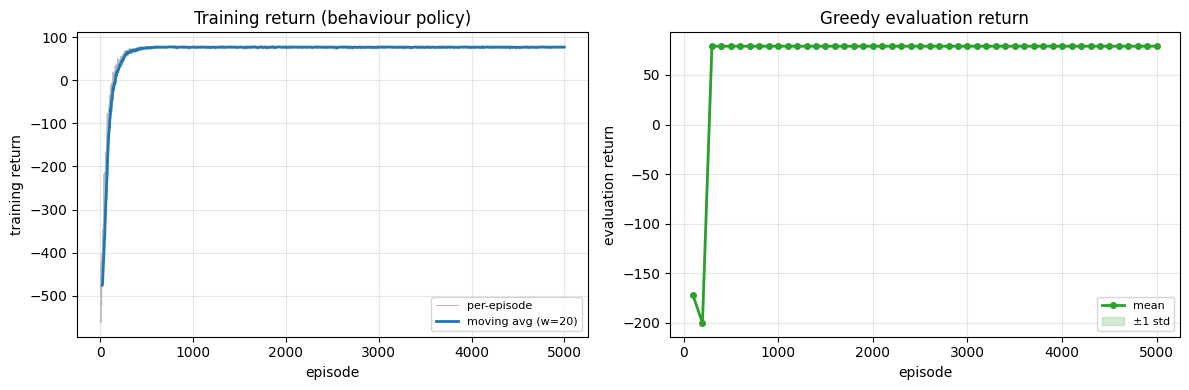

In [ ]:
eps_returns = [x.episode_returns for x in histories]
eval_returns = [x.eval_episodes for x in histories]

eval_mean_returns = [x.eval_mean_returns for x in histories]
eval_std_returns = [x.eval_std_returns for x in histories]

smoothing_window = 20
fig, axes = plt.subplots(1, 2, figsize=(12,4))

ax = axes[0]
returns = np.asarray(np.mean(eps_returns, axis = 0), dtype=np.float64)

episodes = np.arange(1, len(returns) + 1)
ax.plot(episodes, returns, color="#bbbbbb", linewidth=0.8,
        label="per-episode")
if smoothing_window > 1 and len(returns) >= smoothing_window:
    smoothed = np.convolve(
        returns, np.ones(smoothing_window) / smoothing_window, mode="valid"
    )
    ax.plot(
        np.arange(smoothing_window, len(returns) + 1),
        smoothed,
        color="#1f77b4", linewidth=2.0,
        label=f"moving avg (w={smoothing_window})",
    )
ax.set_xlabel("episode")
ax.set_ylabel("training return")
ax.set_title("Training return (behaviour policy)")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)


# --- evaluation return ------------------------------------------------
ax = axes[1]
if history.eval_episodes:
    ep = np.asarray(eval_returns[0])
    mean = np.asarray(np.mean(eval_mean_returns, axis =0))
    std = np.asarray(np.mean(eval_std_returns, axis =0))
    ax.plot(ep, mean, color="#2ca02c", linewidth=2.0, marker="o",
            markersize=4, label="mean")
    ax.fill_between(ep, mean - std, mean + std,
                    color="#2ca02c", alpha=0.2, label="±1 std")
    ax.legend(loc="lower right", fontsize=8)
else:
    ax.text(0.5, 0.5, "no evaluation data\n(set eval_every in train)",
            ha="center", va="center", transform=ax.transAxes,
            color="gray", fontsize=10)
ax.set_xlabel("episode")
ax.set_ylabel("evaluation return")
ax.set_title("Greedy evaluation return")
ax.grid(alpha=0.3)


fig.tight_layout()

plt.show()

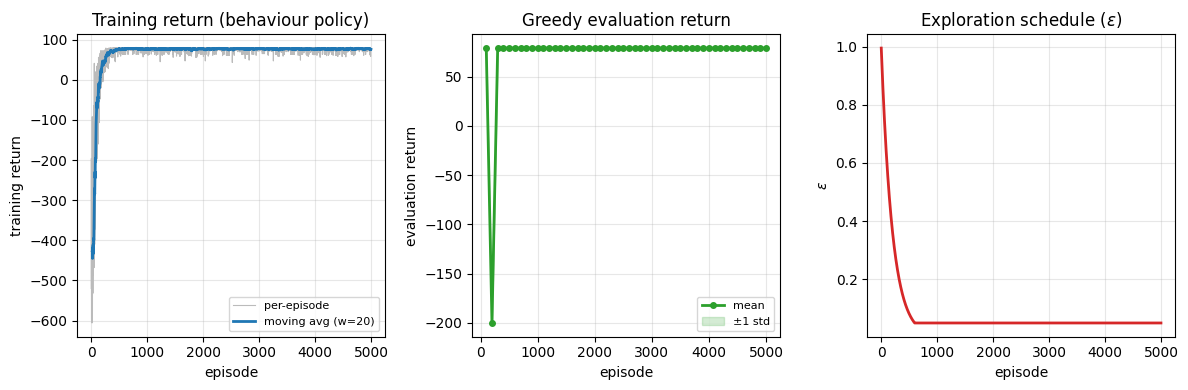

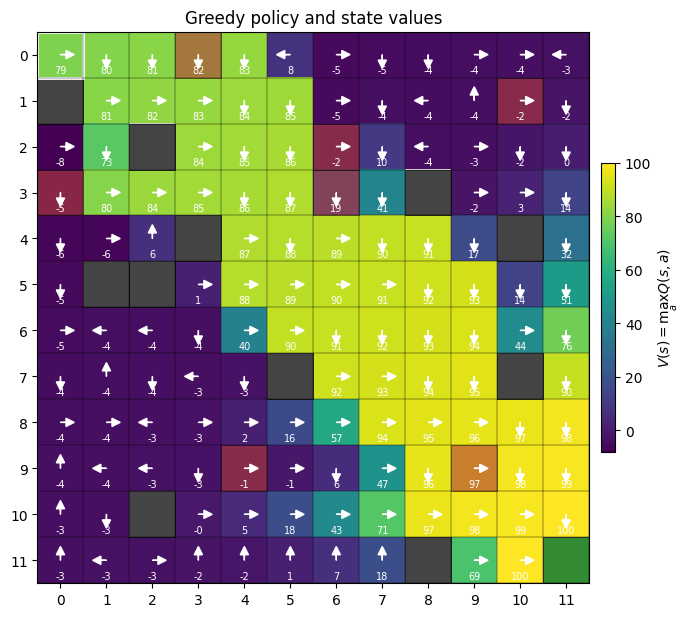

In [27]:
from rlc.utils.plotting import plot_learning_curves, plot_grid_policy_and_values

fig1 = plot_learning_curves(history)
plt.show()

fig2 = plot_grid_policy_and_values(agent, train_env, annotate_values=True, figsize = (7,7))
plt.show()

## Variation of the 1st Case

- Same tabular Q-Learning model, but in this case we don't have a fixed map layout. Instead, each episode includes a completely new random layout.

In [10]:
from rlc.agents.q_learning import QLearningAgent
from rlc.utils.training import train

In [11]:
run_seeds

[42, 12, 33, 100, 133, 24, 99, 56, 1, 72]

In [21]:
results = []
histories = []
for seed in run_seeds:

    # Two environment instances: one for training, one for evaluation.
    train_env = FogGridEnv(
        height=12,
        width=12,
        start_pos=(0, 0),
        goal_pos=(11, 11),
        randomize_map=True,
        obstacle_density= 0.08,
        trap_density=0.05,
        render_mode="rgb_array")

    eval_env = FogGridEnv(
        height=12,
        width=12,
        start_pos=(0, 0),
        goal_pos=(11, 11),
        randomize_map=True,
        obstacle_density= 0.08,
        trap_density=0.05,
        render_mode="rgb_array")

    agent = QLearningAgent(
        n_states=train_env.observation_space.n,
        n_actions=train_env.action_space.n,
        alpha=0.1,
        gamma=1.0,
        epsilon_start=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.995,
        seed = seed
    )

    history = train(
        agent,
        train_env,
        n_episodes=5000,
        max_steps_per_episode=200,
        eval_every=100,
        eval_episodes=100,
        eval_env=eval_env,
        eval_max_steps=200,
        eval_map_setting="fixed",
        eval_map_seed= 123,
        progress=True,
        seed = seed
    )


    print(f"Final epsilon:                     {agent.epsilon:.3f}")
    print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
    print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
        f"(std {history.eval_std_returns[-1]:.1f})")
    print(f"Final evaluation success rate: " f"{history.eval_success_rate[-1] * 100:.1f}%")
    print(f"Final mean episode length: " f"{history.eval_mean_len[-1]:.1f} steps")

    train_succ_rate = np.mean(history.eps_successess)
    histories.append(history)

    print(f"Training success rate: " f"{train_succ_rate * 100:.1f}%")
    
    results.append([agent.epsilon, np.mean(history.episode_returns[-50:]), history.eval_mean_returns[-1],
                            history.eval_std_returns[-1], np.nan,history.eval_success_rate[-1] * 100,
                            history.eval_mean_len[-1], train_succ_rate * 100])

Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -170.8
Final greedy evaluation return:    -871.2 (std 311.5)
Final evaluation success rate: 10.0%
Final mean episode length: 182.6 steps
Training success rate: 87.8%


Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -175.3
Final greedy evaluation return:    -801.5 (std 391.8)
Final evaluation success rate: 17.0%
Final mean episode length: 169.7 steps
Training success rate: 86.4%


Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

...

Final epsilon:                     0.050
Mean return, last 50 train eps:    -149.2
Final greedy evaluation return:    -923.1 (std 225.3)
Final evaluation success rate: 5.0%
Final mean episode length: 191.4 steps
Training success rate: 87.6%


Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -162.4
Final greedy evaluation return:    -757.6 (std 367.2)
Final evaluation success rate: 0.0%
Final mean episode length: 200.0 steps
Training success rate: 88.2%


Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -145.1
Final greedy evaluation return:    -790.6 (std 397.4)
Final evaluation success rate: 18.0%
Final mean episode length: 168.3 steps
Training success rate: 87.8%


In [22]:
random_tql_df = pd.DataFrame(results, columns = ["final epsilon", "mean return last 50 eps", "final greedy eval return_mean", 
                                 "final greedy eval return_std", "weight matrix shape", "evaluation success rate", 
                                 "final mean episode length", "training success rate"])

In [23]:
random_tql_df.describe().T

,count,mean,std,min,25%,50%,75%,max
final epsilon,10.0,0.050000,0.000000,0.050000,0.05000,0.050000,0.050000,0.050000
mean return last 50 eps,10.0,-154.620000,24.095731,-193.440000,-170.48000,-155.770000,-137.505000,-112.560000
final greedy eval return_mean,10.0,-818.126000,90.301473,-923.090000,-873.02000,-825.805000,-793.292500,-608.760000
final greedy eval return_std,10.0,341.315538,61.702686,225.297718,311.26355,359.488446,389.329708,411.236553
weight matrix shape,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
evaluation success rate,10.0,9.600000,6.586181,0.000000,5.50000,10.000000,15.250000,18.000000
final mean episode length,10.0,183.046000,11.706557,168.320000,172.85500,182.400000,190.505000,200.000000
training success rate,10.0,87.644000,0.565277,86.360000,87.46000,87.810000,87.965000,88.240000


In [24]:
# random_tql_df.to_excel("results_TQL_random.xlsx", index=False)

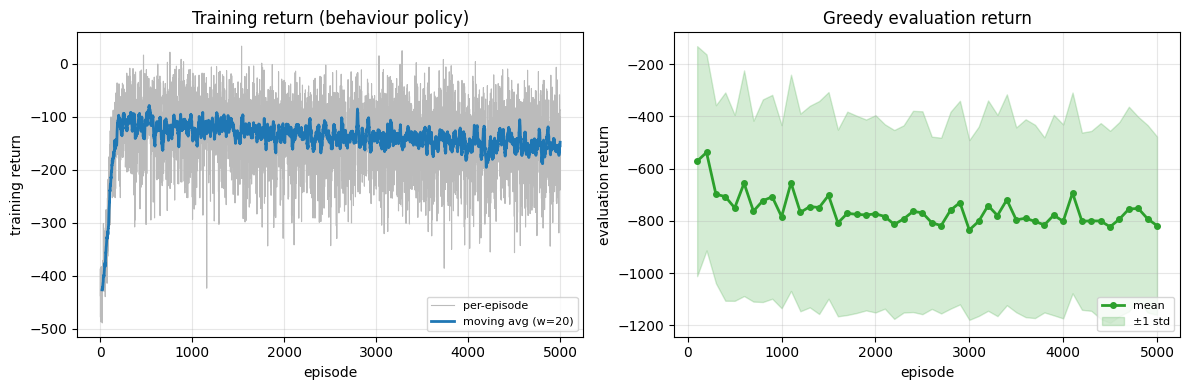

In [25]:
eps_returns = [x.episode_returns for x in histories]
eval_returns = [x.eval_episodes for x in histories]

eval_mean_returns = [x.eval_mean_returns for x in histories]
eval_std_returns = [x.eval_std_returns for x in histories]

smoothing_window = 20
fig, axes = plt.subplots(1, 2, figsize=(12,4))

ax = axes[0]
returns = np.asarray(np.mean(eps_returns, axis = 0), dtype=np.float64)

episodes = np.arange(1, len(returns) + 1)
ax.plot(episodes, returns, color="#bbbbbb", linewidth=0.8,
        label="per-episode")
if smoothing_window > 1 and len(returns) >= smoothing_window:
    smoothed = np.convolve(
        returns, np.ones(smoothing_window) / smoothing_window, mode="valid"
    )
    ax.plot(
        np.arange(smoothing_window, len(returns) + 1),
        smoothed,
        color="#1f77b4", linewidth=2.0,
        label=f"moving avg (w={smoothing_window})",
    )
ax.set_xlabel("episode")
ax.set_ylabel("training return")
ax.set_title("Training return (behaviour policy)")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)


# --- evaluation return ------------------------------------------------
ax = axes[1]
if history.eval_episodes:
    ep = np.asarray(eval_returns[0])
    mean = np.asarray(np.mean(eval_mean_returns, axis =0))
    std = np.asarray(np.mean(eval_std_returns, axis =0))
    ax.plot(ep, mean, color="#2ca02c", linewidth=2.0, marker="o",
            markersize=4, label="mean")
    ax.fill_between(ep, mean - std, mean + std,
                    color="#2ca02c", alpha=0.2, label="±1 std")
    ax.legend(loc="lower right", fontsize=8)
else:
    ax.text(0.5, 0.5, "no evaluation data\n(set eval_every in train)",
            ha="center", va="center", transform=ax.transAxes,
            color="gray", fontsize=10)
ax.set_xlabel("episode")
ax.set_ylabel("evaluation return")
ax.set_title("Greedy evaluation return")
ax.grid(alpha=0.3)


fig.tight_layout()

plt.show()

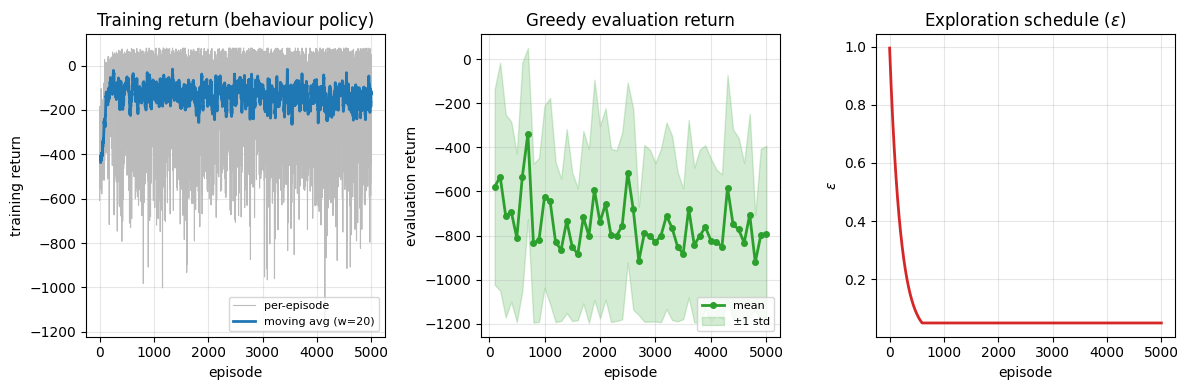

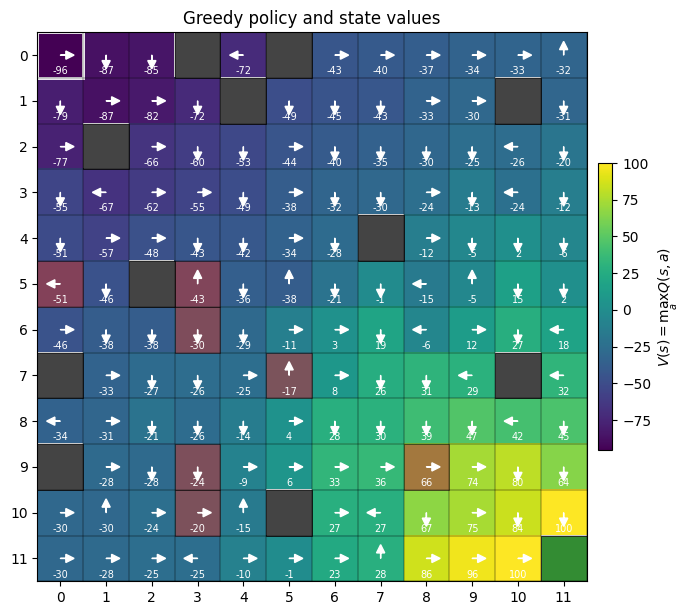

In [26]:
from rlc.utils.plotting import plot_learning_curves, plot_grid_policy_and_values

fig1 = plot_learning_curves(history)
plt.show()

fig2 = plot_grid_policy_and_values(agent, train_env, annotate_values=True, figsize = (7,7))
plt.show()

## 2nd Case

- We create a local view for the agent, so it can lookup tiles that are 2 tiles from it.
- Each observation is now composed of the current position of the agent + the flattened local view.
- This, as the tabular model, will serve as the "index" in which Q-values will be updated for each agent+local view combination.

In [27]:
from rlc.agents.q_learning_wlocal import LocalQLearningAgent
from rlc.utils.training import train


results = []
histories = []
for seed in run_seeds:

    # Two environment instances: one for training, one for evaluation.
    train_env = FogGridEnv(
        height=12,
        width=12,
        start_pos=(0, 0),
        goal_pos=(11, 11),
        randomize_map=True,
        obstacle_density= 0.08,
        trap_density=0.05,
        vision_radius=2,
        local_view= True,
        render_mode="rgb_array")

    eval_env = FogGridEnv(
        height=12,
        width=12,
        start_pos=(0, 0),
        goal_pos=(11, 11),
        randomize_map=True,
        obstacle_density= 0.08,
        trap_density=0.05,
        vision_radius=2,
        local_view= True,
        render_mode="rgb_array")

    agent = LocalQLearningAgent(
        n_actions=train_env.action_space.n,
        alpha=0.001,
        gamma=1.0,
        epsilon_start=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.995,
        seed = seed
    )

    history = train(
        agent,
        train_env,
        n_episodes=5000,
        max_steps_per_episode=200,
        eval_every=100,
        eval_episodes=100,
        eval_env=eval_env,
        eval_max_steps=200,
        eval_map_setting="fixed",
        eval_map_seed= 123,
        progress=True,
        seed = seed
    )


    print(f"Final epsilon:                     {agent.epsilon:.3f}")
    print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
    print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
        f"(std {history.eval_std_returns[-1]:.1f})")
    print(f"Final evaluation success rate: " f"{history.eval_success_rate[-1] * 100:.1f}%")
    print(f"Final mean episode length: " f"{history.eval_mean_len[-1]:.1f} steps")

    train_succ_rate = np.mean(history.eps_successess)
    histories.append(history)

    print(f"Training success rate: " f"{train_succ_rate * 100:.1f}%")
    
    results.append([agent.epsilon, np.mean(history.episode_returns[-50:]), history.eval_mean_returns[-1],
                                history.eval_std_returns[-1], np.nan,history.eval_success_rate[-1] * 100,
                                history.eval_mean_len[-1], train_succ_rate * 100])

Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -309.9
Final greedy evaluation return:    -314.9 (std 265.6)
Final evaluation success rate: 0.0%
Final mean episode length: 200.0 steps
Training success rate: 14.2%


Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -301.1
Final greedy evaluation return:    -306.3 (std 242.9)
Final evaluation success rate: 0.0%
Final mean episode length: 200.0 steps
Training success rate: 14.0%


Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

...

Final epsilon:                     0.050
Mean return, last 50 train eps:    -303.1
Final greedy evaluation return:    -300.2 (std 240.3)
Final evaluation success rate: 0.0%
Final mean episode length: 200.0 steps
Training success rate: 14.2%


Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -306.7
Final greedy evaluation return:    -410.1 (std 343.4)
Final evaluation success rate: 0.0%
Final mean episode length: 200.0 steps
Training success rate: 14.3%


Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -303.5
Final greedy evaluation return:    -310.3 (std 242.3)
Final evaluation success rate: 0.0%
Final mean episode length: 200.0 steps
Training success rate: 14.0%


In [28]:
indexed_random_tql_df = pd.DataFrame(results, columns = ["final epsilon", "mean return last 50 eps", "final greedy eval return_mean", 
                                 "final greedy eval return_std", "weight matrix shape", "evaluation success rate", 
                                 "final mean episode length", "training success rate"])

In [30]:
indexed_random_tql_df.describe().T

,count,mean,std,min,25%,50%,75%,max
final epsilon,10.0,0.050000,0.000000,0.050000,0.050000,0.050000,0.050000,0.050000
mean return last 50 eps,10.0,-301.972000,17.001391,-329.140000,-306.120000,-303.330000,-301.420000,-260.020000
final greedy eval return_mean,10.0,-314.718000,38.801228,-410.100000,-319.395000,-310.070000,-301.730000,-253.740000
final greedy eval return_std,10.0,251.911719,41.495284,173.692292,240.791857,248.250699,263.339468,343.396142
weight matrix shape,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
evaluation success rate,10.0,0.200000,0.632456,0.000000,0.000000,0.000000,0.000000,2.000000
final mean episode length,10.0,199.790000,0.664078,197.900000,200.000000,200.000000,200.000000,200.000000
training success rate,10.0,14.266000,0.466862,13.420000,14.030000,14.190000,14.575000,15.020000


In [ ]:
# indexed_random_tql_df.to_excel("results_IndexQL_random.xlsx", index=False)

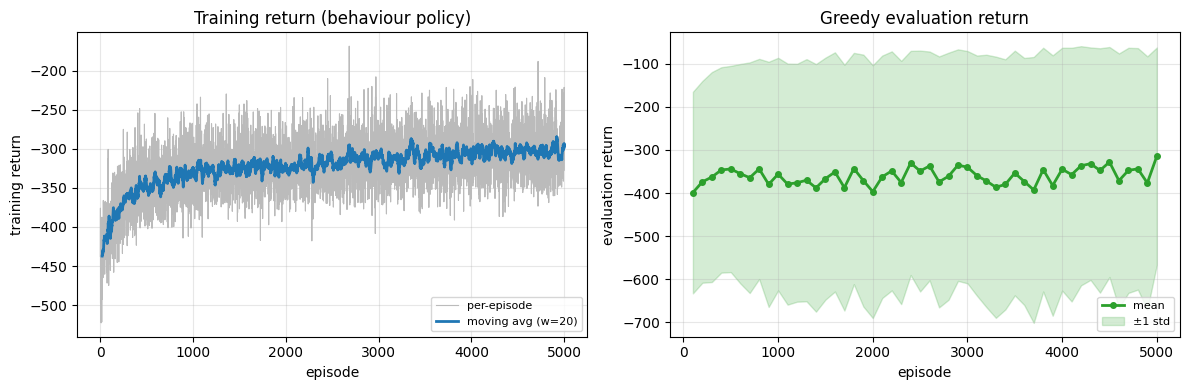

In [31]:
eps_returns = [x.episode_returns for x in histories]
eval_returns = [x.eval_episodes for x in histories]

eval_mean_returns = [x.eval_mean_returns for x in histories]
eval_std_returns = [x.eval_std_returns for x in histories]

smoothing_window = 20
fig, axes = plt.subplots(1, 2, figsize=(12,4))

ax = axes[0]
returns = np.asarray(np.mean(eps_returns, axis = 0), dtype=np.float64)

episodes = np.arange(1, len(returns) + 1)
ax.plot(episodes, returns, color="#bbbbbb", linewidth=0.8,
        label="per-episode")
if smoothing_window > 1 and len(returns) >= smoothing_window:
    smoothed = np.convolve(
        returns, np.ones(smoothing_window) / smoothing_window, mode="valid"
    )
    ax.plot(
        np.arange(smoothing_window, len(returns) + 1),
        smoothed,
        color="#1f77b4", linewidth=2.0,
        label=f"moving avg (w={smoothing_window})",
    )
ax.set_xlabel("episode")
ax.set_ylabel("training return")
ax.set_title("Training return (behaviour policy)")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)


# --- evaluation return ------------------------------------------------
ax = axes[1]
if history.eval_episodes:
    ep = np.asarray(eval_returns[0])
    mean = np.asarray(np.mean(eval_mean_returns, axis =0))
    std = np.asarray(np.mean(eval_std_returns, axis =0))
    ax.plot(ep, mean, color="#2ca02c", linewidth=2.0, marker="o",
            markersize=4, label="mean")
    ax.fill_between(ep, mean - std, mean + std,
                    color="#2ca02c", alpha=0.2, label="±1 std")
    ax.legend(loc="lower right", fontsize=8)
else:
    ax.text(0.5, 0.5, "no evaluation data\n(set eval_every in train)",
            ha="center", va="center", transform=ax.transAxes,
            color="gray", fontsize=10)
ax.set_xlabel("episode")
ax.set_ylabel("evaluation return")
ax.set_title("Greedy evaluation return")
ax.grid(alpha=0.3)


fig.tight_layout()

plt.show()

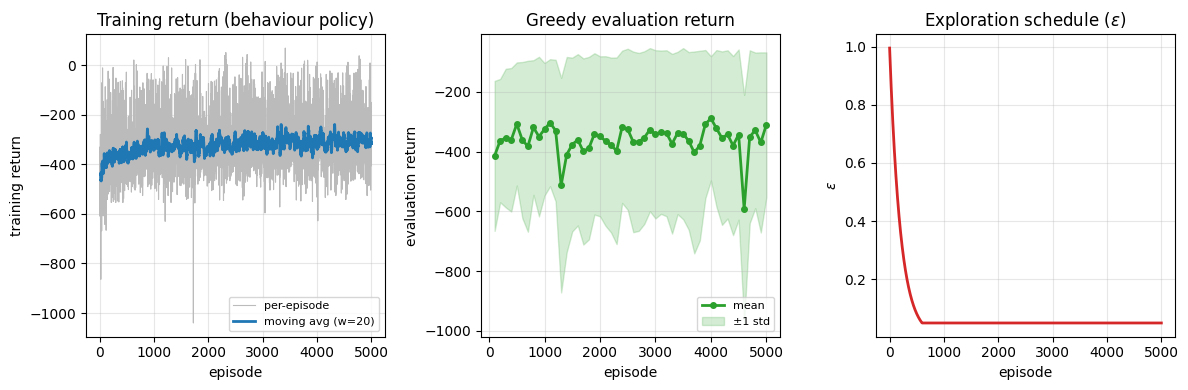

In [42]:
from rlc.utils.plotting import plot_learning_curves

fig1 = plot_learning_curves(history)
plt.show()

# 3rd Case

- We include linera function approximation (LFA), creating a set of features that makes a better generalization in different scenarios.

In [32]:
from rlc.agents.q_learning_LFA import LFAQLearningAgent
from rlc.utils.features import LocalQuadrantFeatures
from rlc.utils.training import train

In [33]:
results = []
histories = []
for seed in run_seeds:
    train_env = FogGridEnv(
        height=12,
        width=12,
        start_pos=(0, 0),
        goal_pos=(11, 11),
        randomize_map=True,
        obstacle_density=0.08,
        trap_density=0.05,
        vision_radius=2,
        local_view=True,
        render_mode="rgb_array",
    )

    eval_env = FogGridEnv(
        height=12,
        width=12,
        start_pos=(0, 0),
        goal_pos=(11, 11),
        randomize_map=True,
        obstacle_density=0.08,
        trap_density=0.05,
        vision_radius=2,
        local_view=True,
        render_mode="rgb_array",
    )

    features = LocalQuadrantFeatures(
        height=train_env.height,
        width=train_env.width,
        vision_radius=2,
        exp_decay=1.0,
        exact_view=True
    )

    # better one: alpha = 0.005
    agent = LFAQLearningAgent(
        n_actions=train_env.action_space.n,
        feature_extractor=features,
        alpha=0.0075,
        gamma=0.97,
        epsilon_start=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.999,
        seed=seed
    )


    history = train(
        agent,
        train_env,
        n_episodes=5000,
        max_steps_per_episode=200,
        eval_every=100,
        eval_episodes=100,
        eval_env=eval_env,
        eval_max_steps=200,
        eval_map_setting="fixed",
        eval_map_seed= 123,
        seed=seed,
        progress=True,
    )
    
    print(f"Final epsilon:                     {agent.epsilon:.3f}")
    print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
    print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
        f"(std {history.eval_std_returns[-1]:.1f})")
    print("Weight matrix size:", agent.weights.shape)
    print("Weight norm:", np.linalg.norm(agent.weights))
    print(f"Final evaluation success rate: " f"{history.eval_success_rate[-1] * 100:.1f}%")
    print(f"Final mean episode length: " f"{history.eval_mean_len[-1]:.1f} steps")

    train_succ_rate = np.mean(history.eps_successess)
    histories.append(history)

    print(f"Training success rate: " f"{train_succ_rate * 100:.1f}%")
    
    
    results.append([agent.epsilon, np.mean(history.episode_returns[-50:]), history.eval_mean_returns[-1],
                    history.eval_std_returns[-1], agent.weights.shape,history.eval_success_rate[-1] * 100,
                    history.eval_mean_len[-1], train_succ_rate * 100])

Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    23.5
Final greedy evaluation return:    19.4 (std 185.1)
Weight matrix size: (4, 132)
Weight norm: 96.27700922539199
Final evaluation success rate: 88.0%
Final mean episode length: 43.4 steps
Training success rate: 73.6%


Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    15.3
Final greedy evaluation return:    -42.6 (std 315.3)
Weight matrix size: (4, 132)
Weight norm: 95.45547999251075
Final evaluation success rate: 87.0%
Final mean episode length: 45.2 steps
Training success rate: 75.6%


Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

...

Final epsilon:                     0.050
Mean return, last 50 train eps:    -103.9
Final greedy evaluation return:    -13.7 (std 230.8)
Weight matrix size: (4, 132)
Weight norm: 96.92652822349098
Final evaluation success rate: 82.0%
Final mean episode length: 54.1 steps
Training success rate: 72.1%


Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -194.0
Final greedy evaluation return:    -223.7 (std 135.0)
Weight matrix size: (4, 132)
Weight norm: 95.00142898099662
Final evaluation success rate: 0.0%
Final mean episode length: 200.0 steps
Training success rate: 66.8%


Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -191.5
Final greedy evaluation return:    -52.0 (std 276.8)
Weight matrix size: (4, 132)
Weight norm: 93.32576294705743
Final evaluation success rate: 75.0%
Final mean episode length: 66.5 steps
Training success rate: 70.1%


In [39]:
LFA_ql_df = pd.DataFrame(results, columns = ["final epsilon", "mean return last 50 eps", "final greedy eval return_mean", 
                                 "final greedy eval return_std", "weight matrix shape", "evaluation success rate", 
                                 "final mean episode length", "training success rate"])

In [ ]:
# LFA_ql_df.to_excel("results_LFA_agent.xlsx", index = False)

In [37]:
pd.read_excel("results_LFA_agent.xlsx").describe().T

,count,mean,std,min,25%,50%,75%,max
final epsilon,10.0,0.050000,0.000000,0.050000,0.050000,0.050000,0.050000,0.050000
mean return last 50 eps,10.0,-44.908000,93.280983,-194.020000,-98.325000,-8.250000,22.975000,53.120000
final greedy eval return_mean,10.0,-102.115000,117.910982,-344.080000,-182.117500,-50.245000,-25.427500,19.440000
final greedy eval return_std,10.0,224.898125,69.230963,132.199962,185.569804,209.496327,288.086891,315.272419
weight matris size,10.0,53.300000,38.870297,0.000000,12.250000,68.500000,85.750000,90.000000
final mean episode length,10.0,105.138000,69.180544,39.800000,47.395000,78.070000,178.200000,200.000000
training success rate,10.0,70.944000,3.530248,66.000000,67.655000,71.700000,73.495000,75.620000


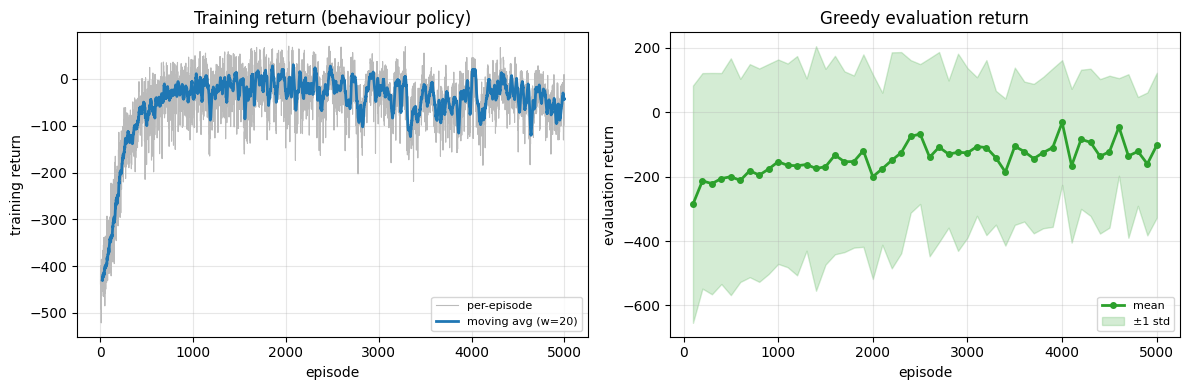

In [38]:
eps_returns = [x.episode_returns for x in histories]
eval_returns = [x.eval_episodes for x in histories]

eval_mean_returns = [x.eval_mean_returns for x in histories]
eval_std_returns = [x.eval_std_returns for x in histories]

smoothing_window = 20
fig, axes = plt.subplots(1, 2, figsize=(12,4))

ax = axes[0]
returns = np.asarray(np.mean(eps_returns, axis = 0), dtype=np.float64)

episodes = np.arange(1, len(returns) + 1)
ax.plot(episodes, returns, color="#bbbbbb", linewidth=0.8,
        label="per-episode")
if smoothing_window > 1 and len(returns) >= smoothing_window:
    smoothed = np.convolve(
        returns, np.ones(smoothing_window) / smoothing_window, mode="valid"
    )
    ax.plot(
        np.arange(smoothing_window, len(returns) + 1),
        smoothed,
        color="#1f77b4", linewidth=2.0,
        label=f"moving avg (w={smoothing_window})",
    )
ax.set_xlabel("episode")
ax.set_ylabel("training return")
ax.set_title("Training return (behaviour policy)")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)


# --- evaluation return ------------------------------------------------
ax = axes[1]
if history.eval_episodes:
    ep = np.asarray(eval_returns[0])
    mean = np.asarray(np.mean(eval_mean_returns, axis =0))
    std = np.asarray(np.mean(eval_std_returns, axis =0))
    ax.plot(ep, mean, color="#2ca02c", linewidth=2.0, marker="o",
            markersize=4, label="mean")
    ax.fill_between(ep, mean - std, mean + std,
                    color="#2ca02c", alpha=0.2, label="±1 std")
    ax.legend(loc="lower right", fontsize=8)
else:
    ax.text(0.5, 0.5, "no evaluation data\n(set eval_every in train)",
            ha="center", va="center", transform=ax.transAxes,
            color="gray", fontsize=10)
ax.set_xlabel("episode")
ax.set_ylabel("evaluation return")
ax.set_title("Greedy evaluation return")
ax.grid(alpha=0.3)


fig.tight_layout()

plt.show()